In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-07-completing-classical-ML\datasets\admissions.csv")
print("shape:", df.shape)
print("admitted rate:", round(df["admitted"].mean(), 2))
df.head()

shape: (100, 3)
admitted rate: 0.61


,exam1,exam2,admitted
0,76.13,73.79,1
1,49.33,60.89,0
2,39.82,68.46,0
3,20.00,74.84,0
4,59.35,87.94,1


In [8]:
df_c0 = df[df['admitted'] == 0]
df_c1 = df[df['admitted'] == 1]

In [9]:
len(df_c0)

39

In [10]:
len(df_c1)

61

In [11]:
df_c1.head()

,exam1,exam2,admitted
0,76.13,73.79,1
4,59.35,87.94,1
5,84.96,68.08,1
6,65.53,89.16,1
8,81.37,62.26,1


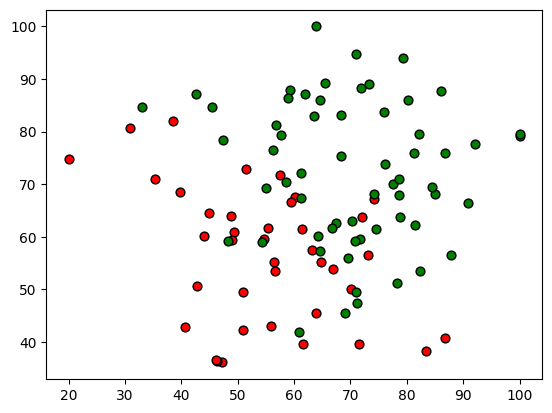

In [13]:
plt.scatter(df_c0['exam1'], df_c0['exam2'], color='red', edgecolor='black', s=40)
plt.scatter(df_c1['exam1'], df_c1['exam2'], color='green', edgecolor='black', s=40)


In [16]:
x_train, x_test, y_train, y_test = train_test_split(df[['exam1', 'exam2']], df['admitted'], test_size=0.25, random_state=10)

In [17]:
print("x train : ", x_train.shape)
print("y train : ", y_train.shape)


print()


print("x test : ", x_test.shape)
print("y test : ", y_test.shape)

x train :  (75, 2)
y train :  (75,)

x test :  (25, 2)
y test :  (25,)


In [19]:
model = SVC(kernel='linear', C=1)

model.fit(x_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
model.coef_

array([[0.09348425, 0.09194977]])

In [22]:
model.intercept_

array([-11.03905528])

In [23]:
pred_train = model.predict(x_train)

In [24]:
pred_train

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int64)

In [25]:
y_train

55    1
21    1
61    1
6     1
63    1
     ..
89    1
28    1
64    1
15    0
9     0
Name: admitted, Length: 75, dtype: int64

In [26]:
accuracy_score(pred_train, y_train)

0.7866666666666666

In [27]:
model.score(x_train, y_train)

0.7866666666666666

In [28]:
pred_test = model.predict(x_test)

In [29]:
accuracy_score(pred_test, y_test)

0.8

In [30]:
model.coef_

array([[0.09348425, 0.09194977]])

In [32]:
w1 = model.coef_[0, 0]
w2 = model.coef_[0, 1]
b = model.intercept_[0]


print(w1)
print(w2)
print(b)

0.09348425291299378
0.09194976752469586
-11.039055279234441


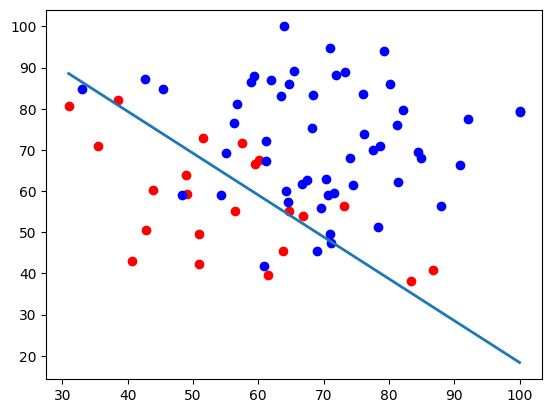

In [40]:
x1_line = np.array([x_train.iloc[:, 0].min(),  x_train.iloc[:, 0].max()])

x2_line = -(w1*x1_line + b)/w2

plt.scatter(x_train.iloc[:, 0][y_train == 0], x_train.iloc[:, 1][y_train == 0], color='red', label="class 0")
plt.scatter(x_train.iloc[:, 0][y_train == 1], x_train.iloc[:, 1][y_train == 1], color='blue', label="class 1")
plt.plot(x1_line, x2_line, label="boundary", lw=2)


In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lo_model = LogisticRegression()

lo_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
lo_model.score(x_train, y_train)

0.7866666666666666

In [44]:
lo_model.score(x_test, y_test)

0.8

In [45]:
lo_model.coef_

array([[0.12177657, 0.12030367]])

In [47]:
w1

0.09348425291299378

In [48]:
w2

0.09194976752469586

In [49]:
lo_model.intercept_

array([-14.37329171])

In [50]:
b

-11.039055279234441

In [51]:
w1 = lo_model.coef_[0, 0]
w2 = lo_model.coef_[0, 1]
b = lo_model.intercept_[0]


print(w1)
print(w2)
print(b)

0.12177656587801672
0.12030366753514977
-14.373291712315218


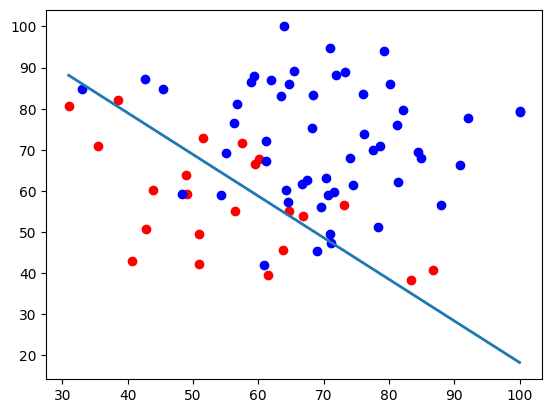

In [52]:
x1_line = np.array([x_train.iloc[:, 0].min(),  x_train.iloc[:, 0].max()])

x2_line = -(w1*x1_line + b)/w2

plt.scatter(x_train.iloc[:, 0][y_train == 0], x_train.iloc[:, 1][y_train == 0], color='red', label="class 0")
plt.scatter(x_train.iloc[:, 0][y_train == 1], x_train.iloc[:, 1][y_train == 1], color='blue', label="class 1")
plt.plot(x1_line, x2_line, label="boundary", lw=2)

In [53]:
import seaborn as sns

<Axes: xlabel='exam1', ylabel='exam2'>

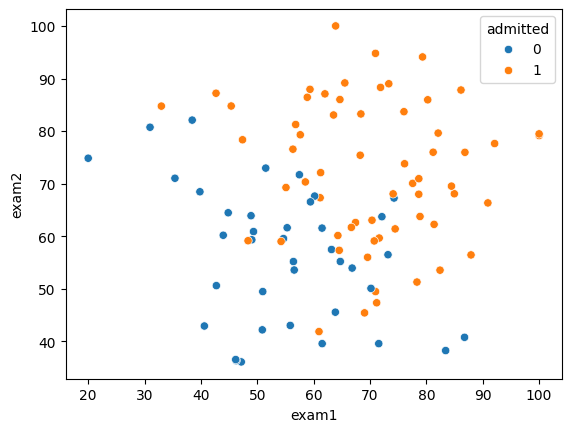

In [55]:
sns.scatterplot(data=df, x='exam1', y='exam2', hue='admitted')

In [57]:
p = np.linspace(0, 1, 100)

In [74]:
h = -p * np.log2(p) - (1- p) * np.log2(1- p)

C:\Users\Abbas\AppData\Local\Temp\ipykernel_18896\2889929882.py:1: RuntimeWarning: divide by zero encountered in log2
  h = -p * np.log2(p) - (1- p) * np.log2(1- p)
C:\Users\Abbas\AppData\Local\Temp\ipykernel_18896\2889929882.py:1: RuntimeWarning: invalid value encountered in multiply
  h = -p * np.log2(p) - (1- p) * np.log2(1- p)


In [75]:
p.shape

(100,)

In [76]:
h.shape

(100,)

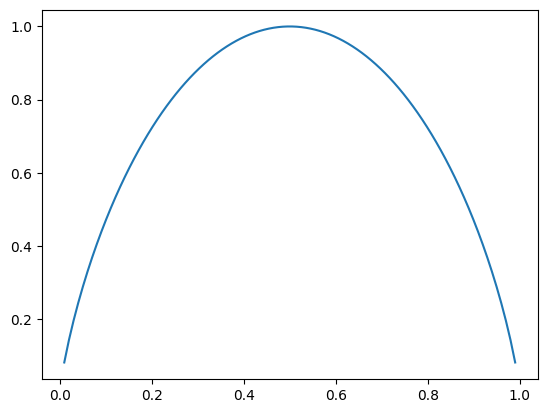

In [77]:
plt.plot(p, h)